In [1]:
import pandas as pd
import geopandas as gpd
import maup
import time
from maup import smart_repair
from gerrychain import Graph

maup.progress.enabled = True

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Alabama
state_ab = "al"

## Data
1. Download all the data in directory "al_data"
3. Extract them all

In [5]:
data_folder = state_ab + "_data/"
population1_data = "./{}{}_pl2020_b/{}_pl2020_p1_b.shp".format(data_folder, state_ab, state_ab)
population2_data = "./{}{}_pl2020_b/{}_pl2020_p2_b.shp".format(data_folder, state_ab, state_ab)
vap_data =  "./{}{}_pl2020_b/{}_pl2020_p4_b.shp".format(data_folder, state_ab, state_ab)
vest20_data = "./{}{}_vest_20/{}_vest_20.shp".format(data_folder, state_ab, state_ab)
vest18_data = "./{}{}_vest_18/{}_vest_18.shp".format(data_folder, state_ab, state_ab)
vest17_data = "./{}{}_vest_17/{}_vest_17.shp".format(data_folder, state_ab, state_ab)
vest16_data = "./{}{}_vest_16/{}_vest_16.shp".format(data_folder, state_ab, state_ab)
elec22_data = "./{}al_gen_22_prec/al_gen_22_no_splits_prec.shp".format(data_folder)
elec24_data = "./{}al_2024_gen_prec/al_2024_gen_all_prec/al_2024_gen_all_prec.shp".format(data_folder)
cd_data = "./{}{}_cong_adopted_2023/SP_Remedial_Plan_3 2023-10-05/SP_Remedial_Plan_3 2023-10-05.shp".format(data_folder, state_ab)
send_data = "./{}{}_sldu_2021/2021 Alabama Senate Plan_shape file.shp".format(data_folder, state_ab)
hdist_data = "./{}{}_sldl_2021/2021 Alabama House Plan_shape file.shp".format(data_folder, state_ab)
county_data = "./{}{}_pl2020_cnty/{}_pl2020_cnty.shp".format(data_folder, state_ab, state_ab)

In [6]:
def do_smart_repair(df, min_rook_length = None, snap_precision = 10, disconnection_threshold=0.0001):
    # change it to the UTM it needs for smart_repair
    df = df.to_crs(df.estimate_utm_crs())
    df = smart_repair(df, min_rook_length = min_rook_length, snap_precision = snap_precision, disconnection_threshold = disconnection_threshold)

    if maup.doctor(df) == False:
        #raise Exception('maup.doctor failed')
        print("maup.doctor failed, please make sure everything looks OK")
    return df

In [7]:
def add_district(dist_df, dist_name, election_df, col_name):
    election_df = election_df.to_crs(election_df.estimate_utm_crs())
    dist_df = dist_df.to_crs(dist_df.estimate_utm_crs())
    # check if it needs to be smart_repair
    if maup.doctor(dist_df) != True:
        dist_df = do_smart_repair(dist_df)

    # assign the pricincts
    precincts_to_district_assignment = maup.assign(election_df.geometry, dist_df.geometry)
    election_df[dist_name] = precincts_to_district_assignment
    for precinct_index in range(len(election_df)):
        election_df.at[precinct_index, dist_name] = dist_df.at[election_df.at[precinct_index, dist_name], col_name]

    return election_df

In [8]:
def rename(original, year):
    party = original[6]
    if party == 'R' or party == 'D':
        return original[3:6] + year + original[6]
    else:
        return original[3:6] + year + 'O'

In [9]:
pop_col = ['TOTPOP', 'HISP', 'NH_WHITE', 'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE', 'H_WHITE', 'H_BLACK', 'H_AMIN', 'H_ASIAN', 'H_NHPI', 'H_OTHER', 'H_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP', '2MOREVAP']

In [10]:
def check_population(population, df):
    pop_check = pd.DataFrame({
        'pop_col': pop_col,
        'population_df': population[pop_col].sum(), 
        'vest_base': df[pop_col].sum(),
        'equal': [x == y for x, y in zip(population[pop_col].sum(), df[pop_col].sum())]
    })
    if pop_check['equal'].mean() < 1:
        print(pop_check)
        raise Exception("population doesn't agree")

    else:
        print("population agrees")

In [11]:
def add_vest(vest, df, year, population, start_col, snap_precision = 10, disconnection_threshold=0.0001):
    df = df.to_crs(df.estimate_utm_crs())
    vest = vest.to_crs(vest.estimate_utm_crs())
    population = population.to_crs(population.estimate_utm_crs())
    df_crs = df.crs
    vest_crs = vest.crs
    
     # check if it needs to be smart_repair
    if maup.doctor(vest) != True:
        vest = do_smart_repair(vest, snap_precision = snap_precision, disconnection_threshold = disconnection_threshold)
    
    # rename the columns
    original_col = vest.columns[start_col:-1]
    new_col = [rename(i, year) for i in original_col]
    rename_dict = dict(zip(original_col, new_col))
    vest = vest.rename(columns=rename_dict)
    vest = vest.groupby(level=0, axis=1).sum() # combine all the other party's vote into columns with sufix "O"
    col_name = list(set(new_col))
    col_name.sort()
    
    # make the blocks from precincts by weight
    vest = gpd.GeoDataFrame(vest, crs=vest_crs)
    election_in_block = population[["VAP", 'geometry']] # population_df is in block scale
    blocks_to_precincts_assignment = maup.assign(election_in_block.geometry, vest.geometry)
    weights = election_in_block["VAP"] / blocks_to_precincts_assignment.map(election_in_block["VAP"].groupby(blocks_to_precincts_assignment).sum())
    weights = weights.fillna(0)
    prorated = maup.prorate(blocks_to_precincts_assignment, vest[col_name], weights)
    election_in_block[col_name] = prorated
    
    # assign blocks to precincts
    election_in_block = gpd.GeoDataFrame(election_in_block, crs=vest_crs)
    df = gpd.GeoDataFrame(df, crs=df_crs)
    block_to_pricinct_assginment = maup.assign(election_in_block.geometry, df.geometry)
    df[col_name] = election_in_block[col_name].groupby(block_to_pricinct_assginment).sum()
    df = df.groupby(level=0, axis=1).sum()
    df = gpd.GeoDataFrame(df, crs = df_crs)
    # check if population agrees
    check_population(population, df)
    
    return df

In [12]:
def add_vest_base(vest, start_col, year, county = None, min_rook_length = None, snap_precision = 10, disconnection_threshold=0.0001):
    vest = vest.to_crs(vest.estimate_utm_crs())
    vest_crs = vest.crs
    original_col = vest.columns[start_col:-1]
    new_col = [rename(i, year) for i in original_col]
    rename_dict = dict(zip(original_col, new_col))
    vest = vest.rename(columns=rename_dict)
    vest = vest.groupby(level=0, axis=1).sum()
    vest = gpd.GeoDataFrame(vest, crs=vest_crs)

    if county is not None:
        county = county.to_crs(county.estimate_utm_crs())
        vest = smart_repair(vest, nest_within_regions = county, min_rook_length = min_rook_length, snap_precision = snap_precision, disconnection_threshold = disconnection_threshold) # nest precincts within counties

    else:
        vest = smart_repair(vest, min_rook_length = min_rook_length, snap_precision = snap_precision) 
    
    return vest

In [13]:
def check_small_boundary_lengths(vest_base):
    import copy
    vest_base = vest_base.to_crs(vest_base.estimate_utm_crs())

    boundaries = copy.deepcopy(vest_base)
    boundaries["geometry"] = boundaries.geometry.boundary  # get boundaries
    neighbors = gpd.sjoin(boundaries, vest_base, predicate="intersects") # find boundaries that intersect
    neighbors = neighbors[neighbors.index != neighbors.index_right] # remove boundaries of a region with itself

    # compute shared border length using intersection
    borders = list(neighbors.apply(
        lambda row: row.geometry.intersection(vest_base.loc[row.index_right, "geometry"]).length, axis=1
    ))

    borders.sort()
    
    return borders

### Read the census data

In [15]:
population1_df = gpd.read_file(population1_data)
population2_df = gpd.read_file(population2_data)
vap_df = gpd.read_file(vap_data)
county_df = gpd.read_file(county_data)

In [16]:
population2_df = population2_df.drop(columns=['SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'geometry'])
vap_df = vap_df.drop(columns=['SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'geometry'])

In [17]:
population_df = pd.merge(population1_df, population2_df, on='GEOID20')
population_df = pd.merge(population_df, vap_df, on='GEOID20')
population_df = population_df.to_crs(population_df.estimate_utm_crs())

In [18]:
maup.doctor(population_df)

100%|█████████████████████████████████| 185976/185976 [01:11<00:00, 2615.78it/s]


True

In [19]:
population_df['H_WHITE'] = population_df.apply(lambda t: t['P0010003'] - t['P0020005'], 1)
population_df['H_BLACK'] = population_df.apply(lambda t: t['P0010004'] - t['P0020006'], 1)
population_df['H_AMIN'] = population_df.apply(lambda t: t['P0010005'] - t['P0020007'], 1)
population_df['H_ASIAN'] = population_df.apply(lambda t: t['P0010006'] - t['P0020008'], 1)
population_df['H_NHPI'] = population_df.apply(lambda t: t['P0010007'] - t['P0020009'], 1)
population_df['H_OTHER'] = population_df.apply(lambda t: t['P0010008'] - t['P0020010'], 1)
population_df['H_2MORE'] = population_df.apply(lambda t: t['P0010009'] - t['P0020011'], 1)

In [20]:
rename_dict = {'P0020001': 'TOTPOP', 'P0020002': 'HISP', 'P0020005': 'NH_WHITE', 'P0020006': 'NH_BLACK', 'P0020007': 'NH_AMIN',
                    'P0020008': 'NH_ASIAN', 'P0020009': 'NH_NHPI', 'P0020010': 'NH_OTHER', 'P0020011': 'NH_2MORE',
                    'P0040001': 'VAP', 'P0040002': 'HVAP', 'P0040005': 'WVAP', 'P0040006': 'BVAP', 'P0040007': 'AMINVAP',
                                        'P0040008': 'ASIANVAP', 'P0040009': 'NHPIVAP', 'P0040010': 'OTHERVAP', 'P0040011': '2MOREVAP'}

In [21]:
population_df.rename(columns=rename_dict, inplace = True)

Make sure that the County shapefile is clean:

In [23]:
maup.doctor(county_df)

100%|██████████████████████████████████████████| 67/67 [00:00<00:00, 315.24it/s]


True

## Read the vest 20 data

Now using it as a "base pricinct"

## Check if vest20 can be used as base

In [26]:
vest20 = gpd.read_file(vest20_data)

In [27]:
vest20.columns

Index(['STATEFP20', 'COUNTYFP20', 'VTDST20', 'GEOID20', 'NAME20', 'G20PRERTRU',
       'G20PREDBID', 'G20PRELJOR', 'G20PREOWRI', 'G20USSRTUB', 'G20USSDJON',
       'G20USSOWRI', 'G20SSCRSHA', 'G20SSCOWRI', 'G20SSCRMEN', 'G20SSCOWR2',
       'G20SACRTHO', 'G20SACOWRI', 'G20SACRFRI', 'G20SACOWR2', 'G20SCCRWIN',
       'G20SCCOWRI', 'G20SCCRKEL', 'G20SCCOWR2', 'G20PSCRCAV', 'G20PSCDCAS',
       'G20PSCOWRI', 'geometry'],
      dtype='object')

In [28]:
start_col = 5
vest_base_data = vest20
year = '20'

In [29]:
vest_base = add_vest_base(vest_base_data, start_col, year, county = county_df, disconnection_threshold = 0)

100%|██████████████████████████████████████████| 67/67 [00:00<00:00, 352.18it/s]


Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.


100%|██████████████████████████████████████████| 67/67 [00:00<00:00, 250.33it/s]


Identifying overlaps...


100%|█████████████████████████████████████| 8446/8446 [00:05<00:00, 1453.18it/s]


Resolving overlaps and filling gaps...


Gaps to fill in region 0: 100%|█████████████████| 24/24 [00:01<00:00, 16.88it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 3: 100%|███████████████| 2/2 [00:00<00:00, 78.10it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 4: 100%|███████████████| 4/4 [00:00<00:00, 81.88it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 5: 100%|███████████████████| 2/2 [00:00<00:00, 73.85it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 9: 100%|███████████████████| 1/1 [00:00<00:00, 58.65it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 12: 100%|██████████████████| 1/1 [00:00<00:00, 38.62it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 14: 1

In [30]:
borders = check_small_boundary_lengths(vest_base)
print(borders[:1000])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [31]:
vest_base = do_smart_repair(vest_base, min_rook_length = 30.5)

Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 2144/2144 [00:00<00:00, 3380.99it/s]


Resolving overlaps...
Filling gaps...


Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


Converting small rook adjacencies to queen...


100%|██████████████████████████████████████| 1972/1972 [00:02<00:00, 657.83it/s]


In [32]:
maup.doctor(vest_base)

100%|██████████████████████████████████████| 1972/1972 [00:02<00:00, 673.22it/s]


True

## If it is true for maup doctor, we will use it as the base vest data.

In [34]:
# vap and population have the same GEOID20
blocks_to_precincts_assignment = maup.assign(population_df.geometry, vest_base.geometry)

100%|███████████████████████████████████████| 1972/1972 [03:40<00:00,  8.93it/s]


In [35]:
vest_base[pop_col] = population_df[pop_col].groupby(blocks_to_precincts_assignment).sum()

In [36]:
election_df = gpd.GeoDataFrame(vest_base)

In [37]:
election_df.columns

Index(['COUNTYFP20', 'GEOID20', 'NAME20', 'PRE20D', 'PRE20O', 'PRE20R',
       'PSC20D', 'PSC20O', 'PSC20R', 'SAC20O', 'SAC20R', 'SCC20O', 'SCC20R',
       'SSC20O', 'SSC20R', 'STATEFP20', 'USS20D', 'USS20O', 'USS20R',
       'VTDST20', 'geometry', 'TOTPOP', 'HISP', 'NH_WHITE', 'NH_BLACK',
       'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE', 'H_WHITE',
       'H_BLACK', 'H_AMIN', 'H_ASIAN', 'H_NHPI', 'H_OTHER', 'H_2MORE', 'VAP',
       'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP',
       '2MOREVAP'],
      dtype='object')

## Check if population agrees

In [39]:
check_population(population_df, vest_base)

population agrees


## Add more vest data

In [41]:
start_col = 5
vest18 = gpd.read_file(vest18_data)
vest17 = gpd.read_file(vest17_data)
vest16 = gpd.read_file(vest16_data)

In [42]:
vest18.columns

Index(['STATEFP20', 'COUNTYFP20', 'VTDST18', 'GEOID18', 'NAME18', 'G18GOVRIVE',
       'G18GOVDMAD', 'G18GOVOWRI', 'G18LTGRAIN', 'G18LTGDBOY', 'G18LTGOWRI',
       'G18ATGRMAR', 'G18ATGDSIE', 'G18ATGOWRI', 'G18TRERMCM', 'G18TREOWRI',
       'G18AGRRPAT', 'G18AGROWRI', 'G18SOSRMER', 'G18SOSDMIL', 'G18SOSOWRI',
       'G18AUDRZEI', 'G18AUDDJOS', 'G18AUDOWRI', 'G18SSCRPAR', 'G18SSCDVAN',
       'G18SSCOWRI', 'G18SSCRSTE', 'G18SSCOWR2', 'G18SSCRBRY', 'G18SSCOWR3',
       'G18SSCRSEL', 'G18SSCOWR4', 'G18SSCRMIT', 'G18SSCDSMA', 'G18SSCOWR5',
       'G18SACREDW', 'G18SACOWRI', 'G18SACRHAN', 'G18SACOWR2', 'G18SACRMOO',
       'G18SACOWR3', 'G18SCCRMIN', 'G18SCCOWRI', 'G18SCCRMCC', 'G18SCCOWR2',
       'G18SCCRCOL', 'G18SCCOWR3', 'G18PSCRODE', 'G18PSCDMCC', 'G18PSCOWRI',
       'G18PSCRBEE', 'G18PSCDPOW', 'G18PSCOWR2', 'geometry'],
      dtype='object')

In [43]:
vest17.columns

Index(['STATEFP20', 'COUNTYFP20', 'VTDST17', 'GEOID17', 'NAME17', 'S17USSRMOO',
       'S17USSDJON', 'S17USSOWRI', 'geometry'],
      dtype='object')

In [44]:
vest16.columns

Index(['STATEFP20', 'COUNTYFP20', 'VTDST16', 'GEOID16', 'NAME16', 'G16PRERTRU',
       'G16PREDCLI', 'G16PRELJOH', 'G16PREGSTE', 'G16PREOWRI', 'G16USSRSHE',
       'G16USSDCRU', 'G16USSOWRI', 'G16SSCRBOL', 'G16SSCOWRI', 'G16SSCRWIS',
       'G16SSCOWR2', 'G16SSCRPAR', 'G16SSCOWR3', 'G16PSCRCAV', 'G16PSCOWRI',
       'geometry'],
      dtype='object')

In [45]:
# check the result here
election_df = add_vest(vest18, election_df, '18', population_df, start_col, disconnection_threshold=0)

100%|██████████████████████████████████████| 1992/1992 [00:03<00:00, 561.48it/s]


There are 714 overlaps.
There are 2253 holes.
There are some invalid geometries.
Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 7718/7718 [00:02<00:00, 2630.59it/s]


Resolving overlaps...
Assigning order 2 pieces...
Assigning order 3 pieces...
Filling gaps...


Gaps to fill: 100%|███████████████████████████| 175/175 [00:23<00:00,  7.39it/s]


100%|██████████████████████████████████████| 1972/1972 [00:15<00:00, 130.92it/s]


population agrees


In [46]:
election_df.columns

Index(['2MOREVAP', 'AGR18O', 'AGR18R', 'AMINVAP', 'ASIANVAP', 'ATG18D',
       'ATG18O', 'ATG18R', 'AUD18D', 'AUD18O', 'AUD18R', 'BVAP', 'COUNTYFP20',
       'GEOID20', 'GOV18D', 'GOV18O', 'GOV18R', 'HISP', 'HVAP', 'H_2MORE',
       'H_AMIN', 'H_ASIAN', 'H_BLACK', 'H_NHPI', 'H_OTHER', 'H_WHITE',
       'LTG18D', 'LTG18O', 'LTG18R', 'NAME20', 'NHPIVAP', 'NH_2MORE',
       'NH_AMIN', 'NH_ASIAN', 'NH_BLACK', 'NH_NHPI', 'NH_OTHER', 'NH_WHITE',
       'OTHERVAP', 'PRE20D', 'PRE20O', 'PRE20R', 'PSC18D', 'PSC18O', 'PSC18R',
       'PSC20D', 'PSC20O', 'PSC20R', 'SAC18O', 'SAC18R', 'SAC20O', 'SAC20R',
       'SCC18O', 'SCC18R', 'SCC20O', 'SCC20R', 'SOS18D', 'SOS18O', 'SOS18R',
       'SSC18D', 'SSC18O', 'SSC18R', 'SSC20O', 'SSC20R', 'STATEFP20', 'TOTPOP',
       'TRE18O', 'TRE18R', 'USS20D', 'USS20O', 'USS20R', 'VAP', 'VTDST20',
       'WVAP', 'geometry'],
      dtype='object')

In [47]:
election_df = add_vest(vest17, election_df, '17', population_df, start_col, disconnection_threshold=0)

100%|██████████████████████████████████████| 1996/1996 [00:03<00:00, 648.71it/s]


There are 732 overlaps.
There are 2364 holes.
There are some invalid geometries.
Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 8248/8248 [00:03<00:00, 2633.37it/s]


Resolving overlaps...
Assigning order 2 pieces...
Assigning order 3 pieces...
Filling gaps...


Gaps to fill: 100%|███████████████████████████| 180/180 [00:24<00:00,  7.33it/s]


100%|██████████████████████████████████████| 1972/1972 [00:15<00:00, 127.93it/s]


population agrees


In [48]:
election_df = add_vest(vest16, election_df, '16', population_df, start_col, disconnection_threshold=0)

100%|██████████████████████████████████████| 2000/2000 [00:03<00:00, 614.39it/s]


There are 738 overlaps.
There are 2449 holes.
There are some invalid geometries.
Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 8403/8403 [00:02<00:00, 2889.56it/s]


Resolving overlaps...
Assigning order 2 pieces...
Assigning order 3 pieces...
Filling gaps...


Gaps to fill: 100%|███████████████████████████| 183/183 [00:24<00:00,  7.38it/s]


100%|██████████████████████████████████████| 1972/1972 [00:14<00:00, 132.19it/s]


population agrees


In [49]:
elec22 = gpd.read_file(elec22_data)
elec24 = gpd.read_file(elec24_data)

In [50]:
elec22 = elec22.drop(['UNIQUE_ID','COUNTYFP','County','Precinct','G22A01NO','G22A01YES','G22A02NO','G22A02YES','G22A03NO','G22A03YES',
                      'G22A04NO','G22A04YES','G22A05NO','G22A05YES','G22A06NO','G22A06YES','G22A07NO','G22A07YES','G22A08NO','G22A08YES',
                      'G22A09NO','G22A09YES','G22A10NO','G22A10YES','G22CNSNO','G22CNSYES','G22CNSNO','G22CNSYES','G22LTGLPAG','G22LTGOWRI',
                      'G22LTGRAIN','G22PS1LBIS','G22PS1OWRI','G22PS1RODE','G22PS2LLAN','G22PS2OWRI','G22PS2RBEE','GCON01LREM','GCON01OWRI',
                      'GCON01RCAR','GCON02DHAR','GCON02LREA','GCON02OWRI','GCON02RMOO','GCON03DVEA','GCON03IBEL','GCON03LCAS','GCON03OWRI',
                      'GCON03RROG','GCON04DNEI','GCON04LCOC','GCON04OWRI','GCON04RADE','GCON05DWAR','GCON05LGRE','GCON05OWRI','GCON05RSTR',
                      'GCON06LCHI','GCON06OWRI','GCON06RPAL','GCON07DSEW','GCON07LGOO','GCON07OWRI','GCON07RNIC','GSL001OWRI','GSL001RPET',
                      'GSL002OWRI','GSL002RHAR','GSL003DTHO','GSL003OWRI','GSL003RUND','GSL004OWRI','GSL004RMOO','GSL005OWRI','GSL005RCRA',
                      'GSL006LTUR','GSL006OWRI','GSL006RWHI','GSL007DJON','GSL007LDUR','GSL007OWRI','GSL007RYAR','GSL008LWAL','GSL008OWRI',
                      'GSL008RCOL','GSL009LBOD','GSL009OWRI','GSL009RSTA','GSL010DLAN','GSL010LBOY','GSL010OWRI','GSL010RCOL','GSL011OWRI',
                      'GSL011RSHE','GSL012DFIE','GSL012OWRI','GSL012RHAR','GSL013LDAV','GSL013OWRI','GSL013RWOO','GSL014OWRI','GSL014RWAD',
                      'GSL015DROU','GSL015OWRI','GSL015RHUL','GSL016OWRI','GSL016RSOU','GSL017OWRI','GSL017REST','GSL018LSHI','GSL018OWRI',
                      'GSL018RKIE','GSL019DHAL','GSL019OWRI','GSL020OWRI','GSL020RLOM','GSL021OWRI','GSL021RREY','GSL022OWRI','GSL022RWHO',
                      'GSL023OWRI','GSL023RKIR','GSL024OWRI','GSL024RLED','GSL025DHAG','GSL025OWRI','GSL025RRIG','GSL026DALF','GSL026OWRI',
                      'GSL026RCOL','GSL027DNEU','GSL027OWRI','GSL027RKIT','GSL028OWRI','GSL028RBUT','GSL029LVAL','GSL029OWRI','GSL029RGID',
                      'GSL030OWRI','GSL030RLIP','GSL031OWRI','GSL031RSTU','GSL032DBOY','GSL032OWRI','GSL032RJAC','GSL033DCRU','GSL033OWRI',
                      'GSL033RROB','GSL034OWRI','GSL034RSTA','GSL035OWRI','GSL035RHUR','GSL036OWRI','GSL036RWOO','GSL037OWRI','GSL037RFIN',
                      'GSL038LTEM','GSL038OWRI','GSL038RWOO','GSL039OWRI','GSL039RSHA','GSL040DHOW','GSL040OWRI','GSL040RROB','GSL041DNEL',
                      'GSL041LMOR','GSL041OWRI','GSL041RELL','GSL042LWAR','GSL042OWRI','GSL042RSMI','GSL043DCLE','GSL043LBUR','GSL043OWRI',
                      'GSL043RMOO','GSL044LBOO','GSL044OWRI','GSL044RGAR','GSL045LWHI','GSL045OWRI','GSL045RDUB','GSL046OWRI','GSL046RFAU',
                      'GSL047DCOL','GSL047OWRI','GSL047RSHA','GSL048LSTU','GSL048OWRI','GSL048RCAR','GSL049OWRI','GSL049RBED','GSL050OWRI',
                      'GSL050RHIL','GSL051OWRI','GSL051RTRE','GSL052DROG','GSL052OWRI','GSL053DDAN','GSL053OWRI','GSL054DRAF','GSL054OWRI',
                      'GSL055DPLU','GSL055OWRI','GSL056DTIL','GSL056LLES','GSL056OWRI','GSL057DSEL','GSL057LJON','GSL057OWRI','GSL057RBAU',
                      'GSL058DHOL','GSL058OWRI','GSL059DMOO','GSL059OWRI','GSL060DGIV','GSL060LFRE','GSL060OWRI','GSL061LPRU','GSL061OWRI',
                      'GSL061RBOL','GSL062DCEP','GSL062OWRI','GSL062RLAM','GSL063DADA','GSL063OWRI','GSL063RALM','GSL064LMAY','GSL064OWRI',
                      'GSL064RGIV','GSL065DCAS','GSL065OWRI','GSL065REAS','GSL066OWRI','GSL066RBAK','GSL067DCHE','GSL067OWRI','GSL068DJAC',
                      'GSL068OWRI','GSL068RKEL','GSL069DLAW','GSL069OWRI','GSL069RMAD','GSL070DENG','GSL070OWRI','GSL071DMCC','GSL071OWRI',
                      'GSL072DTRA','GSL072OWRI','GSL073OWRI','GSL073RPAS','GSL074DENS','GSL074OWRI','GSL074RMEA','GSL075OWRI','GSL075RING',
                      'GSL076DMCC','GSL076LMAN','GSL076OWRI','GSL077DMOR','GSL077OWRI','GSL078DHAS','GSL078OWRI','GSL079LFRI','GSL079OWRI',
                      'GSL079RLOV','GSL080OWRI','GSL080RBLA','GSL081OWRI','GSL081ROLI','GSL082DWAR','GSL082OWRI','GSL082RPIE','GSL083DGRA',
                      'GSL083OWRI','GSL084DFOR','GSL084OWRI','GSL085DGRI','GSL085OWRI','GSL085RREH','GSL086OWRI','GSL086RLEE','GSL087OWRI',
                      'GSL087RSOR','GSL088LMAY','GSL088OWRI','GSL088RSTA','GSL089OWRI','GSL089RPAR','GSL090OWRI','GSL090RSEL','GSL091OWRI',
                      'GSL091RMAR','GSL092DHUB','GSL092OWRI','GSL092RHAM','GSL093OWRI','GSL093RCLO','GSL094LHEL','GSL094OWRI','GSL094RFID',
                      'GSL095DBRA','GSL095OWRI','GSL095RHOL','GSL096OWRI','GSL096RSIM','GSL097DCLA','GSL097OWRI','GSL098DBRA','GSL098OWRI',
                      'GSL099DJON','GSL099OWRI','GSL100LWAR','GSL100OWRI','GSL100RSHI','GSL101OWRI','GSL101RPRI','GSL102OWRI','GSL102RSTR',
                      'GSL103DDRU','GSL103OWRI','GSL104LDEA','GSL104OWRI','GSL104RWIL','GSL105LLEW','GSL105OWRI','GSL105RBRO','GSU01OWRI',
                      'GSU01RMEL','GSU02DLEW','GSU02OWRI','GSU02RBUT','GSU03LCHA','GSU03OWRI','GSU03RORR','GSU04OWRI','GSU04RGUD',
                      'GSU05OWRI','GSU05RREE','GSU06LRIC','GSU06OWRI','GSU06RSTU','GSU07DWIL','GSU07OWRI','GSU07RGIV','GSU08OWRI',
                      'GSU08RLIV','GSU09OWRI','GSU09RSCO','GSU10OWRI','GSU10RJON','GSU11OWRI','GSU11RBEL','GSU12DMCC','GSU12OWRI','GSU12RKEL',
                      'GSU13OWRI','GSU13RPRI','GSU14OWRI','GSU14RWEA','GSU15LCRU','GSU15OWRI','GSU15RROB','GSU16OWRI','GSU16RWAG',
                      'GSU17LFOR','GSU17OWRI','GSU17RSHE','GSU18DSMI','GSU18OWRI','GSU19DCOL','GSU19LWIL','GSU19OWRI','GSU20DCOL','GSU20OWRI',
                      'GSU21DWAR','GSU21OWRI','GSU21RALL','GSU22OWRI','GSU22RALB','GSU23DSTE','GSU23LSHE','GSU23OWRI','GSU23RNIM','GSU24DSIN',
                      'GSU24LBEN','GSU24OWRI','GSU25LWOO','GSU25OWRI','GSU25RBAR','GSU26DHAT','GSU26OWRI','GSU27DREE','GSU27OWRI','GSU27RHOV',
                      'GSU28DBEA','GSU28LBOA','GSU28OWRI','GSU29DMAT','GSU29LMCB','GSU29OWRI','GSU29RCHE','GSU30OWRI','GSU30RCHA','GSU31OWRI',
                      'GSU31RCAR','GSU32OWRI','GSU32RELL','GSU33DFIG','GSU33OWRI','GSU33RRIE','GSU34OWRI','GSU34RWIL','GSU35LHUD','GSU35OWRI',
                      'GSU35RSES',], axis = 1)

In [51]:
elec22.columns

Index(['G22AGRLCLA', 'G22AGROWRI', 'G22AGRRPAT', 'G22AJ5DKEL', 'G22AJ5OWRI',
       'G22AJ5RCOO', 'G22AJ6OWRI', 'G22AJ6RWIS', 'G22ATGDMAJ', 'G22ATGOWRI',
       'G22ATGRMAR', 'G22AUDLLAC', 'G22AUDOWRI', 'G22AUDRSOR', 'G22GOVDFLO',
       'G22GOVLBLA', 'G22GOVOWRI', 'G22GOVRIVE', 'G22SOSDLAF', 'G22SOSLSHE',
       'G22SOSOWRI', 'G22SOSRALL', 'G22TRELHAM', 'G22TREOWRI', 'G22TRERBOO',
       'G22USSDBOY', 'G22USSLSOP', 'G22USSOWRI', 'G22USSRBRI', 'geometry'],
      dtype='object')

In [52]:
elec24 = elec24.drop(['UNIQUE_ID','COUNTYFP','County','Precinct','G24A01NO','G24A01YES','G24AJ1OWRI','G24AJ1RMCC','G24AJ2OWRI','G24AJ2RBRY',
                      'G24AJ3OWRI','G24AJ3RSEL','G24AJ4OWRI','G24AJ4RMIT','G24CR1OWRI','G24CR1RMIN','G24CR2OWRI','G24CR2RAND','G24CR3OWRI',
                      'G24CR3RCOL','G24CV1OWRI','G24CV1REDW','G24CV2OWRI','G24CV2RHAN','G24CV3OWRI','G24CV3RMOO','G24PSCOWRI','G24PSCRCAV',
                      'GCON01DHOL','GCON01OWRI','GCON01RMOO','GCON02DFIG','GCON02OWRI','GCON02RDOB','GCON03OWRI','GCON03RROG','GCON04OWRI',
                      'GCON04RADE','GCON05OWRI','GCON05RSTR','GCON06DAND','GCON06OWRI','GCON06RPAL','GCON07DSEW','GCON07OWRI','GCON07RLIT',], axis=1)

In [53]:
elec24.columns

Index(['G24CFJDGRI', 'G24CFJOWRI', 'G24CFJRSTE', 'G24PREDHAR', 'G24PREIKEN',
       'G24PREIOLI', 'G24PREISTE', 'G24PREOWRI', 'G24PRERTRU', 'geometry'],
      dtype='object')

In [54]:
election_df = add_vest(elec22, election_df, '22', population_df, 0, disconnection_threshold=0)

100%|██████████████████████████████████████| 1939/1939 [00:02<00:00, 671.46it/s]


There are 977 overlaps.
There are 3316 holes.
There are some invalid geometries.
Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|███████████████████████████████████| 10218/10218 [00:03<00:00, 3244.84it/s]


Resolving overlaps...
Assigning order 2 pieces...
Couldn't find a polygon to glue a component in the intersection of geometries {144, 156} to
Assigning order 3 pieces...
1 gaps will remain unfilled, because they either are not simply connected or exceed the area threshold.
Filling gaps...


Gaps to simplify: 3986it [07:47,  8.52it/s]                                     
Gaps to fill: 100%|███████████████████████████| 314/314 [00:44<00:00,  7.12it/s]


100%|██████████████████████████████████████| 1939/1939 [00:02<00:00, 656.43it/s]


There are 2 holes.
maup.doctor failed, please make sure everything looks OK


100%|██████████████████████████████████████| 1972/1972 [00:15<00:00, 126.98it/s]


population agrees


In [55]:
election_df = add_vest(elec24, election_df, '24', population_df, 0, disconnection_threshold = 0)

100%|██████████████████████████████████████| 1947/1947 [00:03<00:00, 577.60it/s]


There are 3 holes.
Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 2209/2209 [00:00<00:00, 3508.19it/s]


Resolving overlaps...
Assigning order 2 pieces...
Assigning order 3 pieces...
2 gaps will remain unfilled, because they either are not simply connected or exceed the area threshold.
Filling gaps...


Gaps to simplify: 100%|███████████████████████████| 2/2 [00:00<00:00, 11.49it/s]
Gaps to fill: 0it [00:00, ?it/s]


100%|██████████████████████████████████████| 1947/1947 [00:03<00:00, 640.52it/s]


There are 2 holes.
maup.doctor failed, please make sure everything looks OK


100%|██████████████████████████████████████| 1972/1972 [00:15<00:00, 130.44it/s]


population agrees


##  Add the district data

In [57]:
cd = gpd.read_file(cd_data)
cd = cd.to_crs(cd.estimate_utm_crs())
send = gpd.read_file(send_data)
send = send.to_crs(send.estimate_utm_crs())
hdist = gpd.read_file(hdist_data)
hdist = hdist.to_crs(hdist.estimate_utm_crs())

In [58]:
cd.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,AP_WHT,...,F_BLACK,F_AP_WHT,F_AP_BLK,F_18_POP,F_18_WHT,F_18_BLK,F_18_AP_WH,F_18_AP_BL,DISTRICT_L,geometry
0,1,8126.240234,1,1.0,None,None,717754,527330,116462,566761,...,0.162259,0.789631,0.176664,0.776500,0.756601,0.154792,0.801127,0.162527,1|0%,"POLYGON ((385902.039 3446182.236, 386260.117 3..."
1,2,9562.906250,2,1.0,None,None,717754,303461,353228,328547,...,0.492130,0.457743,0.508510,0.778346,0.449861,0.475491,0.478634,0.486920,2|0%,"POLYGON ((604645.184 3595635.494, 604682.987 3..."
2,3,6873.106934,3,1.0,None,None,717754,508080,146376,539477,...,0.203936,0.751618,0.217629,0.786614,0.724094,0.199346,0.759849,0.206950,3|0%,"POLYGON ((539096.378 3736215.239, 539095.924 3..."
3,4,8855.813477,4,1.0,None,None,717754,585183,49721,621226,...,0.069273,0.865514,0.079028,0.773548,0.838022,0.067366,0.879986,0.072246,4|0%,"POLYGON ((381649.018 3711216.978, 381652.226 3..."
4,5,4067.180420,5,1.0,None,None,717754,495427,126226,543486,...,0.175862,0.757204,0.192877,0.780777,0.712173,0.173328,0.766675,0.183322,5|0%,"MULTIPOLYGON (((578020.242 3821654.887, 578019..."


In [59]:
election_df = add_district(cd, "CD", election_df, "DISTRICT")

100%|█████████████████████████████████████████████| 7/7 [00:00<00:00,  8.88it/s]


In [60]:
send.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,F18_POP,...,F_BLACK,DISTRICT_N,F_18_BLK,F_18_WHT,F_18_IND,F_18_ASN,F_18_HWN,F_18_OTH,DISTRICT_L,geometry
0,1,1086.042840,1,1.0,None,SD1,145951,121263,12323,115624,...,0.084432,1,0.082111,0.847212,0.004662,0.008035,0.000355,0.016606,1|1.67%,"POLYGON ((514462.766 3843057.116, 514349.698 3..."
1,2,1410.311890,10,1.0,None,sd10,150508,117298,16384,117304,...,0.108858,10,0.106535,0.802650,0.007868,0.006777,0.000307,0.033818,10|4.85%,"POLYGON ((636421.929 3821242.165, 636477.872 3..."
2,3,994.453674,11,1.0,None,SD11,147539,108122,29242,114732,...,0.198198,11,0.194906,0.746984,0.003024,0.005622,0.000218,0.011906,11|2.78%,"POLYGON ((559485.231 3685522.834, 559475.882 3..."
3,4,990.664062,12,1.0,None,SD12,150048,103388,34321,118726,...,0.228733,12,0.223675,0.705928,0.003967,0.010006,0.000842,0.015919,12|4.53%,"POLYGON ((577037.042 3663163.332, 577007.837 3..."
4,5,2634.800040,13,1.0,None,SD13,149072,103758,34198,115310,...,0.229406,13,0.225141,0.711499,0.003807,0.009375,0.000529,0.013338,13|3.85%,"POLYGON ((647933.352 3759333.665, 648010.770 3..."


In [61]:
election_df = add_district(send, "SEND", election_df, "DISTRICT")

100%|███████████████████████████████████████████| 35/35 [00:01<00:00, 27.16it/s]


In [62]:
hdist.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,AMINDIAN,...,F_18_ASN,F_18_HWN,ALTERNATE7,POLSBY_PO7,F_AMINDIAN,F_ASIAN,F_HAWAIIAN,F_OTHER,DISTRICT_L,geometry
0,1,369.111603,1,1.0,None,None,49457,41637,4206,171,...,0.007259,0.000253,1.879437,0.283103,0.003458,0.007461,0.000324,0.014983,1|3.36%,"POLYGON ((399682.554 3861638.621, 399673.156 3..."
1,2,107.224449,10,1.0,None,None,50200,29591,10655,376,...,0.051483,0.001154,1.698433,0.346659,0.007490,0.050697,0.001454,0.047629,10|4.91%,"POLYGON ((533376.532 3823778.124, 533358.283 3..."
2,3,73.417282,100,1.0,None,None,47686,33540,8351,313,...,0.038790,0.000584,1.887102,0.280808,0.006564,0.040180,0.000503,0.016776,100|-0.34%,"POLYGON ((380991.103 3386601.994, 380990.978 3..."
3,4,41.136116,101,1.0,None,None,45885,31138,10237,219,...,0.026185,0.000715,2.142793,0.217791,0.004773,0.025324,0.000741,0.016716,101|-4.11%,"POLYGON ((387953.988 3398181.502, 387978.104 3..."
4,5,718.522278,102,1.0,None,None,48195,36017,6682,2029,...,0.004039,0.000163,2.467290,0.164270,0.042100,0.004129,0.000187,0.011163,102|0.72%,"POLYGON ((401755.453 3429805.975, 401733.325 3..."


In [63]:
election_df = add_district(hdist, "HDIST", election_df, "DISTRICT")

100%|█████████████████████████████████████████| 105/105 [00:02<00:00, 48.88it/s]


In [64]:
maup.doctor(election_df)

100%|██████████████████████████████████████| 1972/1972 [00:02<00:00, 674.86it/s]


True

### Put the base precinct year after the precinct information column

In [66]:
base_columns = {}
if 'COUNTYFP' + year not in election_df.columns:
    base_columns = {
        'STATEFP':'STATEFP'+year,
        'COUNTYFP':'COUNTYFP'+year,
        'VTDST':'VTDST'+year,
        'GEOID':'GEOID'+year,
        'NAME':'NAME'+year}
election_df.rename(columns=base_columns, inplace = True)

In [67]:
# reorder the columns
fixed_columns = [
    'STATEFP'+year,
    'COUNTYFP'+year,
    'VTDST'+year,
    'GEOID'+year,
    'NAME'+year,
    'CD',
    'SEND',
    'HDIST',
    'TOTPOP',
    'NH_2MORE',
    'NH_AMIN',
    'NH_ASIAN',
    'NH_BLACK',
    'NH_NHPI',
    'NH_OTHER',
    'NH_WHITE',
    'HISP',
    'H_AMIN',
    'H_ASIAN',
    'H_BLACK',
    'H_NHPI',
    'H_OTHER',
    'H_WHITE',
    'H_2MORE',
    'VAP',
    'HVAP',
    'WVAP',
    'BVAP',
    'AMINVAP',
    'ASIANVAP',
    'NHPIVAP',
    'OTHERVAP',
    '2MOREVAP']

election_columns = [col for col in election_df.columns if col not in fixed_columns]
final_col = fixed_columns + election_columns
election_df = election_df[final_col]

In [68]:
import os

# store the result in directory "il"
directory = "./{}".format(state_ab)
if not os.path.exists(directory):
    os.makedirs(directory)

shapefile_path = "./{}/{}.shp".format(state_ab, state_ab)
geojson_path = './{}/{}.geojson'.format(state_ab, state_ab)
json_path = "./{}.json".format(state_ab, state_ab)

# Check if the shapefile or geojson file already exists
if os.path.exists(shapefile_path):
    os.remove(shapefile_path)
if os.path.exists(geojson_path):
    os.remove(geojson_path)

election_df.to_file(shapefile_path)
election_df.to_file(geojson_path, driver='GeoJSON')

# Only do once to build json and read from file when generating ensembles
graph = Graph.from_file(shapefile_path, ignore_errors=True)
graph.to_json(json_path)

<Axes: >

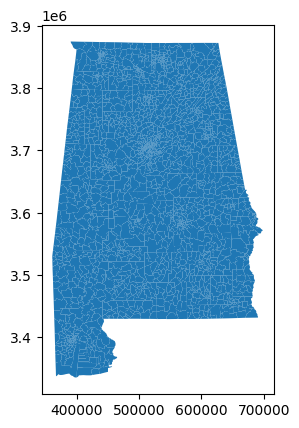

In [69]:
shapefile_path = "./{}/{}.shp".format(state_ab, state_ab)
shape=gpd.read_file(shapefile_path)
shape.plot()

In [70]:
election_df.columns

Index(['STATEFP20', 'COUNTYFP20', 'VTDST20', 'GEOID20', 'NAME20', 'CD', 'SEND',
       'HDIST', 'TOTPOP', 'NH_2MORE',
       ...
       'USS17D', 'USS17O', 'USS17R', 'USS20D', 'USS20O', 'USS20R', 'USS22D',
       'USS22O', 'USS22R', 'geometry'],
      dtype='object', length=120)

In [71]:
list(election_df.columns)

['STATEFP20',
 'COUNTYFP20',
 'VTDST20',
 'GEOID20',
 'NAME20',
 'CD',
 'SEND',
 'HDIST',
 'TOTPOP',
 'NH_2MORE',
 'NH_AMIN',
 'NH_ASIAN',
 'NH_BLACK',
 'NH_NHPI',
 'NH_OTHER',
 'NH_WHITE',
 'HISP',
 'H_AMIN',
 'H_ASIAN',
 'H_BLACK',
 'H_NHPI',
 'H_OTHER',
 'H_WHITE',
 'H_2MORE',
 'VAP',
 'HVAP',
 'WVAP',
 'BVAP',
 'AMINVAP',
 'ASIANVAP',
 'NHPIVAP',
 'OTHERVAP',
 '2MOREVAP',
 'AGR18O',
 'AGR18R',
 'AGR22O',
 'AGR22R',
 'AJ522D',
 'AJ522O',
 'AJ522R',
 'AJ622O',
 'AJ622R',
 'ATG18D',
 'ATG18O',
 'ATG18R',
 'ATG22D',
 'ATG22O',
 'ATG22R',
 'AUD18D',
 'AUD18O',
 'AUD18R',
 'AUD22O',
 'AUD22R',
 'CFJ24D',
 'CFJ24O',
 'CFJ24R',
 'GOV18D',
 'GOV18O',
 'GOV18R',
 'GOV22D',
 'GOV22O',
 'GOV22R',
 'LTG18D',
 'LTG18O',
 'LTG18R',
 'PRE16D',
 'PRE16O',
 'PRE16R',
 'PRE20D',
 'PRE20O',
 'PRE20R',
 'PRE24D',
 'PRE24O',
 'PRE24R',
 'PSC16O',
 'PSC16R',
 'PSC18D',
 'PSC18O',
 'PSC18R',
 'PSC20D',
 'PSC20O',
 'PSC20R',
 'SAC18O',
 'SAC18R',
 'SAC20O',
 'SAC20R',
 'SCC18O',
 'SCC18R',
 'SCC20O',
 'SCC

In [72]:
len(election_df.columns)

120